# Lecture 26

# Classification with scikit-learn: iris data

## Week 10 Friday

## Miles Chen, PhD

Classification in the standard scikit-learn workflow:

1. Put the predictor variables in `X` and the labels in `y`.
2. Split the data into training and test sets.
3. Create a model object.
4. Fit the model with `.fit()`.
5. Predict labels with `.predict()`.
6. Evaluate the predictions.

The main idea is the workflow. K-nearest neighbors and Naive Bayes are examples of classifiers, not the only possible choices.


In [1]:
# Core data tools
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt


In [2]:
from sklearn.datasets import load_iris  # built-in example data set


## 1. Load and inspect the iris data

The iris data set is a small built-in scikit-learn data set. Each row is one flower, the four numeric columns are flower measurements, and the target is the species.


In [3]:
iris = load_iris()
type(iris)  # A Bunch behaves a lot like a dictionary.


sklearn.utils._bunch.Bunch

In [4]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

A scikit-learn data set often stores separate pieces:

- `data`: predictor variables, often called `X`
- `target`: response labels, often called `y`
- `feature_names`: names of the predictor columns
- `target_names`: names for the target categories


In [5]:
print(iris.data[:10, :])  # first 10 flowers; 4 measurement columns


[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]]


In [6]:
print(iris.feature_names)  # names of the four predictor variables


['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [7]:
iris.target  # species stored as numeric codes: 0, 1, 2


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [8]:
print(iris.target_names)  # what the numeric target codes mean


['setosa' 'versicolor' 'virginica']


In [9]:
# The full description is long, but useful for seeing where the data came from.
print(iris.DESCR)


.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

## 2. Split into training and test data

The model learns from the training data. The test data is held back so we can check how the model performs on observations it did not train on.


In [10]:
from sklearn.model_selection import train_test_split

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 20% test data, 80% training data
    random_state=1,    # makes the split reproducible
    stratify=y,        # keeps class proportions similar in both sets
)


In [11]:
X_train.shape  # 120 training rows, 4 predictor columns


(120, 4)

In [12]:
print(np.bincount(y_train))
print(np.bincount(y_test))
# Each class is represented in both sets.


[40 40 40]
[10 10 10]


## 3. Fit a k-nearest neighbors classifier

K-nearest neighbors predicts a new flower by looking at the labels of the most similar flowers in the training data.

The main parameter here is `n_neighbors`: how many nearby training observations get a vote.


Before fitting a model, it is useful to visualize the predictor variables. A good classifier can take advantage of patterns where the classes separate from each other.


In [13]:
import seaborn as sns


In [14]:
dat = pd.DataFrame(X_train, columns=iris.feature_names)
dat["species"] = y_train
dat.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.7,1.5,0.4,0
1,4.6,3.2,1.4,0.2,0
2,6.9,3.1,5.1,2.3,2
3,5.5,2.6,4.4,1.2,1
4,5.6,2.9,3.6,1.3,1


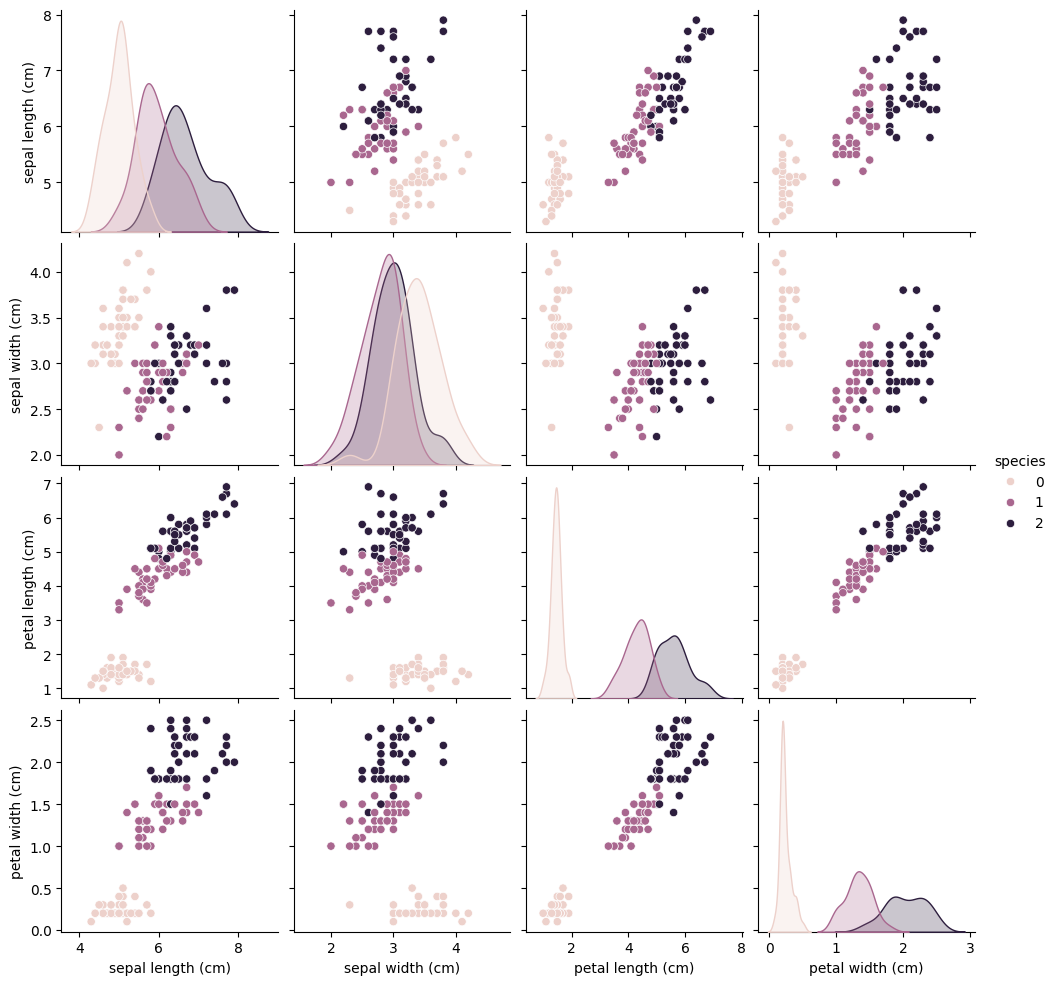

In [15]:
sns.pairplot(dat, hue="species");


The scikit-learn pattern is usually:

`model = Classifier(...)`

`model.fit(X_train, y_train)`

`model.predict(X_test)`


In [16]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)


In [17]:
print(knn)

KNeighborsClassifier()


In [18]:
knn.fit(X_train, y_train)  # learn from the training data


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [19]:
y_pred = knn.predict(X_test)
print(y_pred)  # predictions based on the fitted model


[2 0 1 0 0 0 2 2 2 1 0 1 2 1 2 0 2 1 1 2 1 1 0 0 2 1 0 0 1 1]


In [20]:
print(y_test)  # actual labels for the test set


[2 0 1 0 0 0 2 2 2 1 0 1 2 1 2 0 2 1 1 2 1 1 0 0 2 2 0 0 1 1]


In [21]:
from sklearn.metrics import accuracy_score, confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)
print("Test accuracy:", accuracy_score(y_test, y_pred))

# Rows are the true species; columns are the predicted species.
# No errors would mean all the counts are on the diagonal.


[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]
Test accuracy: 0.9666666666666667


Accuracy tells us how many predictions were correct. The confusion matrix tells us which mistakes the classifier made.


In [22]:
# Try a more flexible KNN model: only one nearest neighbor gets a vote.
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train, y_train)
confusion_matrix(y_test, knn1.predict(X_test))


array([[10,  0,  0],
       [ 0, 10,  0],
       [ 0,  1,  9]])

In [23]:
# Try a smoother KNN model: 25 neighbors get a vote.
knn25 = KNeighborsClassifier(n_neighbors=25)
knn25.fit(X_train, y_train)
confusion_matrix(y_test, knn25.predict(X_test))

# More neighbors can reduce sensitivity to individual points, but may blur class boundaries.


array([[10,  0,  0],
       [ 0, 10,  0],
       [ 0,  2,  8]])

## 4. Automated parameter search with GridSearchCV

What if we want to test many different KNN settings?

Instead of manually fitting one model with 1 neighbor, another model with 2 neighbors, another with 3 neighbors, and so on, we can ask Python to try a grid of settings for us.

`GridSearchCV` tries each parameter combination and scores it with cross-validation.

Important: the grid search is fit only on the training data. The test data stays hidden until the final evaluation.


In [24]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_neighbors": np.arange(1, 50),
    "weights": ["uniform", "distance"],
}

knn = KNeighborsClassifier()  # no n_neighbors here; GridSearchCV will choose it
knn_cv = GridSearchCV(
    knn,
    param_grid,
    cv=5,
)

# cv=5 means each parameter combination is scored with 5-fold cross-validation.
# We are still using only the training data for this search.


In [25]:
knn_cv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': array([ 1, 2..., 47, 48, 49]), 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is als

In [26]:
knn_cv.best_params_  # parameters with the best mean cross-validation score


{'n_neighbors': np.int64(13), 'weights': 'uniform'}

In [27]:
knn_cv.best_score_  # mean cross-validation accuracy for the best parameter setting


np.float64(0.9833333333333334)

Now evaluate the selected model. The training score tells us how well it does on data it saw during fitting. The test score is a better estimate of performance on new data.


In [28]:
best_knn = knn_cv.best_estimator_

train_pred = best_knn.predict(X_train)
print(confusion_matrix(y_train, train_pred))
print("Training accuracy:", accuracy_score(y_train, train_pred))


[[40  0  0]
 [ 0 38  2]
 [ 0  0 40]]
Training accuracy: 0.9833333333333333


In [29]:
test_pred = best_knn.predict(X_test)
print(confusion_matrix(y_test, test_pred))
print("Test accuracy:", accuracy_score(y_test, test_pred))


[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]
Test accuracy: 0.9666666666666667


In [30]:
from sklearn.model_selection import cross_val_score

# cross_val_score is useful when you want CV scores without a full grid search.
cv_scores = cross_val_score(best_knn, X_train, y_train, cv=5)
print(cv_scores)
print("Mean CV accuracy:", np.mean(cv_scores))


[0.95833333 1.         1.         1.         0.95833333]
Mean CV accuracy: 0.9833333333333334


## 5. Gaussian Naive Bayes

Naive Bayes is a different classifier. The important point for today is that scikit-learn uses the same fit, predict, and evaluate pattern across many models.


In [31]:
from sklearn.naive_bayes import GaussianNB

nbclass = GaussianNB()


In [32]:
nbclass.fit(X_train, y_train)


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [33]:
nb_pred = nbclass.predict(X_test)
nb_pred


array([2, 0, 1, 0, 0, 0, 2, 2, 2, 1, 0, 1, 2, 1, 2, 0, 2, 1, 1, 2, 1, 1,
       0, 0, 2, 1, 0, 0, 1, 1])

In [34]:
print(confusion_matrix(y_test, nb_pred))
print("Test accuracy:", accuracy_score(y_test, nb_pred))


[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]
Test accuracy: 0.9666666666666667


In [35]:
nb_cv_scores = cross_val_score(nbclass, X_train, y_train, cv=5)
nb_cv_scores


array([0.91666667, 0.95833333, 0.95833333, 0.95833333, 0.95833333])

In [36]:
np.mean(nb_cv_scores)


np.float64(0.95)